# 📝 Problem Statement

Credit card fraud represents a major challenge in the financial sector, leading to significant financial losses for institutions and customers worldwide. With the rapid growth of digital payments, detecting fraudulent transactions accurately and efficiently has become a critical requirement.

One of the primary challenges of fraud detection lies in the **severely imbalanced nature of transaction data**, where fraudulent transactions account for only a very small percentage of all transactions. As a result, traditional classification models often become biased toward the majority (legitimate) class, leading to poor detection of fraud cases.

This project focuses on developing a **machine learning–based fraud detection system** capable of identifying fraudulent credit card transactions while minimizing missed fraud cases. Emphasis is placed on achieving **high recall**, as failing to detect fraudulent activity can result in substantial financial and security risks.

The project follows a structured pipeline that includes data exploration, preprocessing, imbalance handling, model training, and comprehensive evaluation to ensure reliable and realistic performance.

---

## 🎯 Objectives

- Perform exploratory data analysis (EDA) to understand transaction patterns and feature behavior.  
- Clean and preprocess the dataset to ensure data quality and model compatibility.  
- Address the **class imbalance problem** using appropriate techniques and model-level strategies.  
- Train and compare multiple machine learning models for fraud detection.  
- Apply ensemble learning methods to improve fraud detection performance.  
- Evaluate models using appropriate metrics such as **recall**, **precision**, **F1-score**, **ROC-AUC**, and **confusion matrix**, with particular focus on recall.

---

## 📊 Dataset Overview

The dataset consists of anonymized credit card transaction records collected over a period of time. Each transaction includes customer, merchant, temporal, and location-based features, along with a target label indicating whether the transaction is fraudulent.

- `is_fraud = 0` → Legitimate Transaction  
- `is_fraud = 1` → Fraudulent Transaction  

The dataset is **highly imbalanced**, with fraudulent transactions representing a very small fraction of the total data. This imbalance necessitates careful model selection, evaluation strategies, and the use of recall-oriented techniques to ensure effective fraud detection.


# Libraries

In [96]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import zscore
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.ensemble import BalancedRandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier

# Data Understanding

In [2]:
df = pd.read_csv("../Data/creditcard(1).csv")

In [3]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
df.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
820457,820457,2019-12-08 20:32:14,502038091380,"fraud_Turcotte, Batz and Buckridge",health_fitness,73.89,Kurt,Peters,M,7290 Ashlee Keys,...,36.6704,-93.0377,1201,"Engineer, agricultural",1980-03-18,bf62d42e4d7dd32e03e9d44df3cda992,1354998734,36.162825,-92.366452,0
1049052,1049052,2020-03-10 19:15:44,4400011257587661852,fraud_Leannon-Ward,food_dining,4.48,Marissa,Powell,F,474 Allen Haven,...,41.4972,-98.7858,509,"Nurse, children's",1980-09-15,2635d8ed4bd7fa41b34de4a4b7da606c,1362942944,42.209102,-98.150233,0
13457,13457,2019-01-08 15:54:09,4826655832045236,"fraud_Haley, Batz and Auer",health_fitness,56.21,Tami,Forbes,F,5204 Robinson Plaza Suite 897,...,41.6983,-70.3001,1850,Counselling psychologist,1963-12-29,cc0ceb3c574a2a37845b048d943c8dc4,1326038049,42.320092,-71.284677,0
773162,773162,2019-11-27 02:03:20,180040027502291,fraud_Emard Inc,gas_transport,64.63,Mary,Schmidt,F,022 Moore Island,...,40.7699,-73.9511,1577385,Audiological scientist,1957-12-29,274b29be190da4ae8b7e912d2ffa4ff5,1353981800,39.891928,-72.957861,0
807977,807977,2019-12-06 13:37:41,6011252220172077,fraud_Pfeffer and Sons,shopping_pos,184.92,Melvin,Wright,M,210 Dean Causeway Suite 130,...,42.9782,-96.0173,1700,"Engineer, land",2001-12-19,70c33aac7f694af3beb37961cf937da8,1354801061,42.065574,-96.705596,0
200514,200514,2019-04-13 13:29:45,371034293500716,fraud_Lubowitz-Walter,kids_pets,50.41,Jeremy,Jones,M,5758 Yates Center,...,40.0235,-120.7986,128,Education administrator,1966-02-21,eda06e7aab6c4604a0b99c42ad99f237,1334323785,39.848055,-120.289672,0
367580,367580,2019-06-19 14:40:26,3598215285024754,"fraud_Reichert, Shanahan and Hayes",shopping_net,1.71,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,d182dd0ac236bd4c2ff878b94c50f726,1340116826,41.165610,-72.674499,0
649639,649639,2019-10-03 23:01:33,4755696071492,"fraud_Monahan, Hermann and Johns",travel,3.66,Robert,Evans,M,01892 Patricia Vista Apt. 828,...,32.9643,-96.6012,20328,Site engineer,1985-06-20,e59f91170ff63421e688726117e08422,1349305293,32.156926,-96.431034,0
195085,195085,2019-04-10 19:11:29,4792627764422477317,fraud_Harris Group,food_dining,80.54,Margaret,Mendez,F,7952 Karen Pike,...,38.9462,-94.9714,5760,Chief Executive Officer,1978-10-01,65e6a3c045c9a6ac14391f23b895dcf8,1334085089,39.168422,-94.988329,0
1293656,1293656,2020-06-20 09:12:54,4170689372027579,fraud_Cummerata-Jones,gas_transport,50.59,Samuel,Frey,M,830 Myers Plaza Apt. 384,...,35.6665,-97.4798,116001,Media buyer,1993-05-10,8bbb686e535b28999dd7361eeed574ee,1371719574,36.405594,-97.141506,0


In [5]:
df.shape

(1296675, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [7]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [8]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [9]:
df.nunique()

Unnamed: 0               1296675
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

In [10]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [11]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

# Data cleaning

In [12]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['amt'] < lower_bound) | (df['amt'] > upper_bound)]
outliers.shape

(67290, 23)

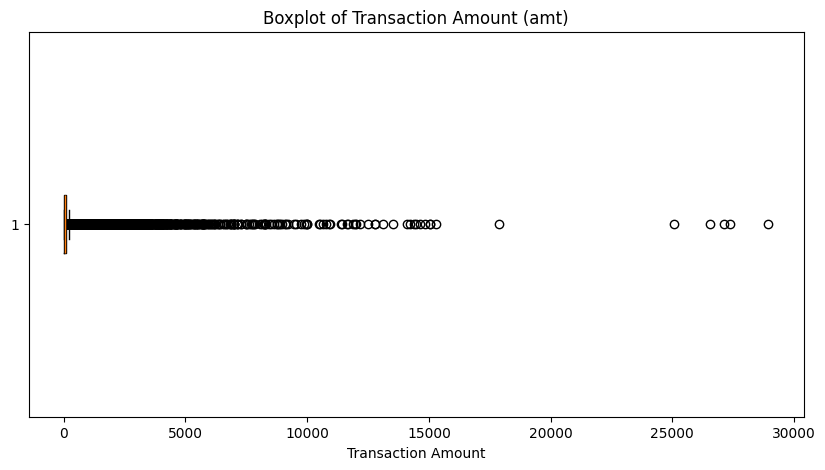

In [15]:
plt.figure(figsize=(10, 5))
plt.boxplot(df['amt'], vert=False)
plt.title("Boxplot of Transaction Amount (amt)")
plt.xlabel("Transaction Amount")
plt.show()

# Exploratory Data Analysis (EDA)

## EDA (Univariate Analysis)

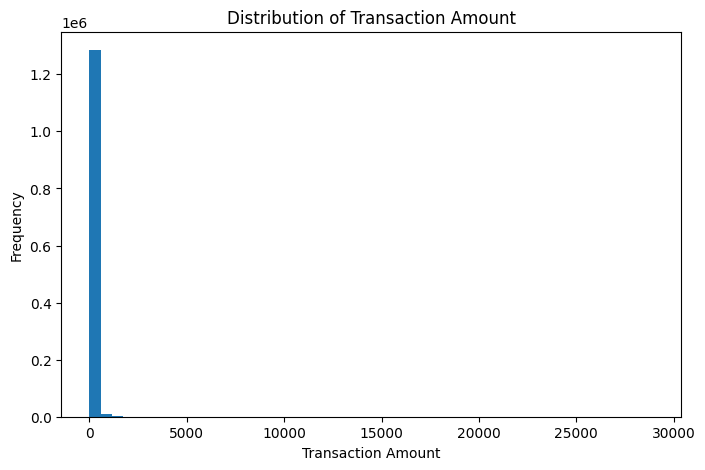

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df['amt'], bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

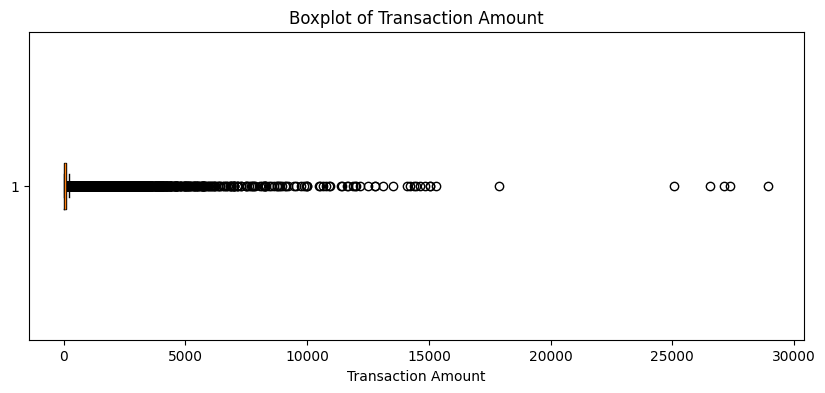

In [17]:
plt.figure(figsize=(10,4))
plt.boxplot(df['amt'], vert=False)
plt.title("Boxplot of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.show()

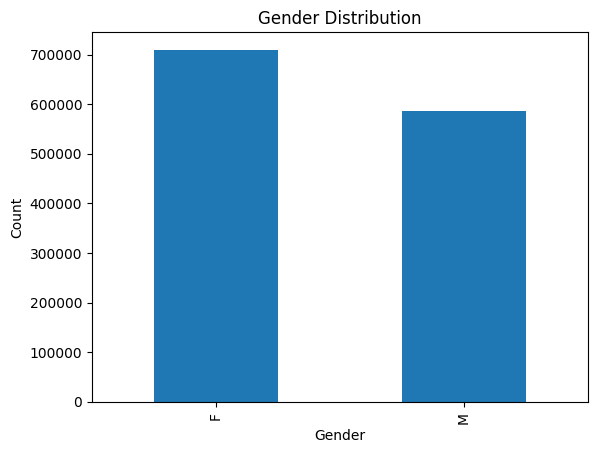

In [18]:
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

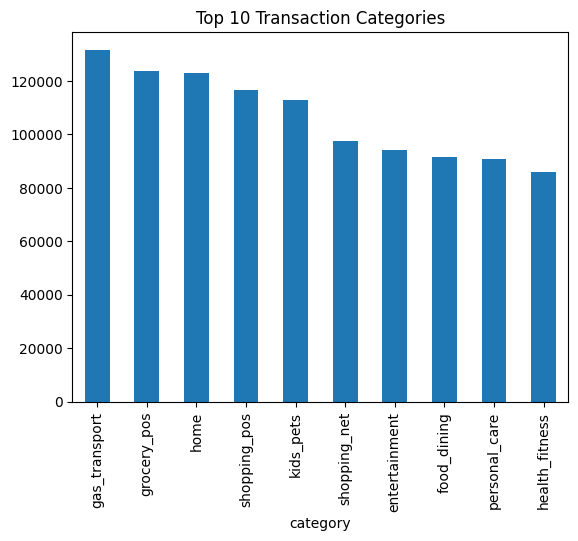

In [19]:
df['category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Transaction Categories")
plt.show()


In [20]:
df['amt'].skew(), df['amt'].kurt()

(np.float64(42.2778737900512), np.float64(4545.644979374182))

In [21]:
df['amt_log'] = np.log1p(df['amt'])

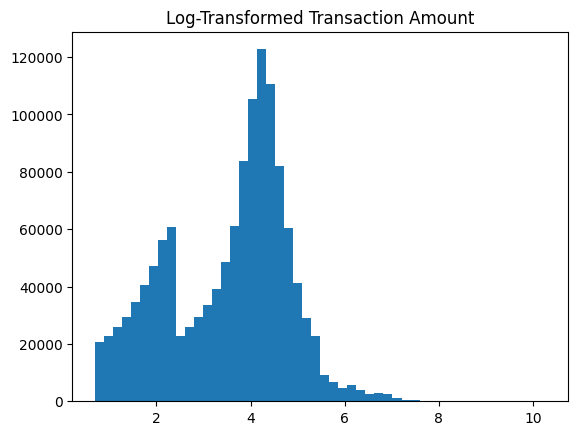

In [22]:
plt.hist(df['amt_log'], bins=50)
plt.title("Log-Transformed Transaction Amount")
plt.show()

## EDA (Bivariate Analysis)

In [23]:
corr_matrix = df.select_dtypes(include=['int64','float64']).corr()
corr_matrix

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,amt_log
Unnamed: 0,1.000000,0.000386,-0.000251,0.000709,0.000602,-0.000676,-0.001678,0.998971,0.000541,-0.000671,-0.004767,0.000284
cc_num,0.000386,1.000000,0.001769,0.041459,-0.059271,-0.048278,-0.008991,0.000354,-0.058942,-0.048252,-0.000981,0.004801
amt,-0.000251,0.001769,1.000000,0.001843,-0.001926,-0.000187,0.005818,-0.000293,-0.001873,-0.000151,0.219404,0.496001
zip,0.000709,0.041459,0.001843,1.000000,-0.114290,-0.909732,0.078467,0.000670,-0.113561,-0.908924,-0.002162,0.002159
lat,0.000602,-0.059271,-0.001926,-0.114290,1.000000,-0.015533,-0.155730,0.000632,0.993592,-0.015509,0.001894,0.009887
long,-0.000676,-0.048278,-0.000187,-0.909732,-0.015533,1.000000,-0.052715,-0.000642,-0.015452,0.999120,0.001721,-0.000603
city_pop,-0.001678,-0.008991,0.005818,0.078467,-0.155730,-0.052715,1.000000,-0.001714,-0.154781,-0.052687,0.002136,-0.003976
unix_time,0.998971,0.000354,-0.000293,0.000670,0.000632,-0.000642,-0.001714,1.000000,0.000561,-0.000635,-0.005078,0.000266
merch_lat,0.000541,-0.058942,-0.001873,-0.113561,0.993592,-0.015452,-0.154781,0.000561,1.000000,-0.015431,0.001741,0.009852
merch_long,-0.000671,-0.048252,-0.000151,-0.908924,-0.015509,0.999120,-0.052687,-0.000635,-0.015431,1.000000,0.001721,-0.000583


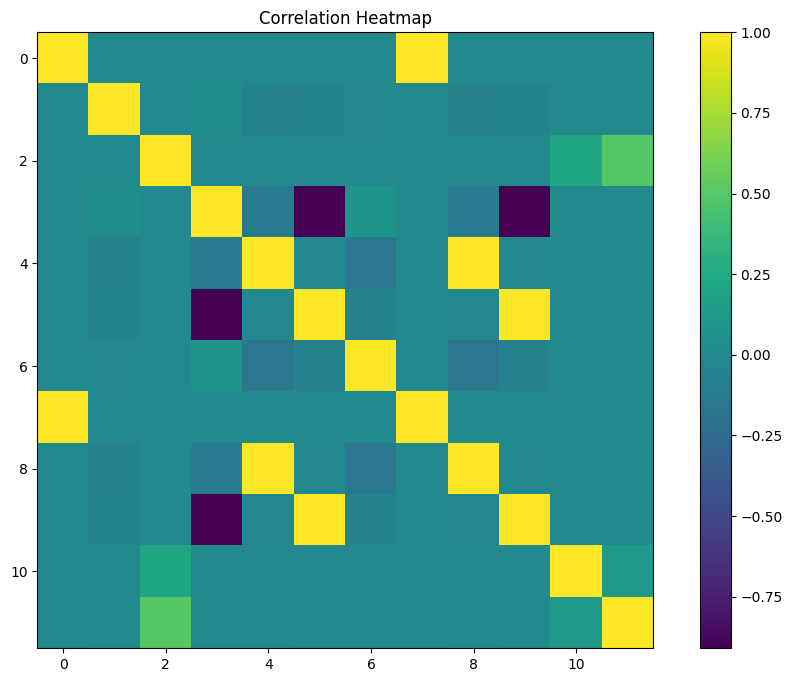

In [24]:
plt.figure(figsize=(12,8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

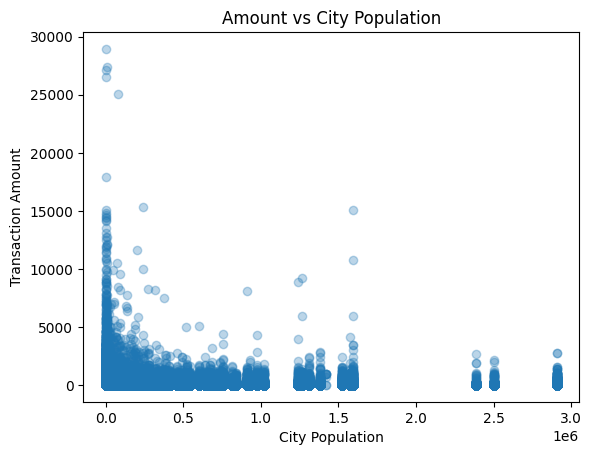

In [25]:
plt.scatter(df['city_pop'], df['amt'], alpha=0.3)
plt.xlabel("City Population")
plt.ylabel("Transaction Amount")
plt.title("Amount vs City Population")
plt.show()

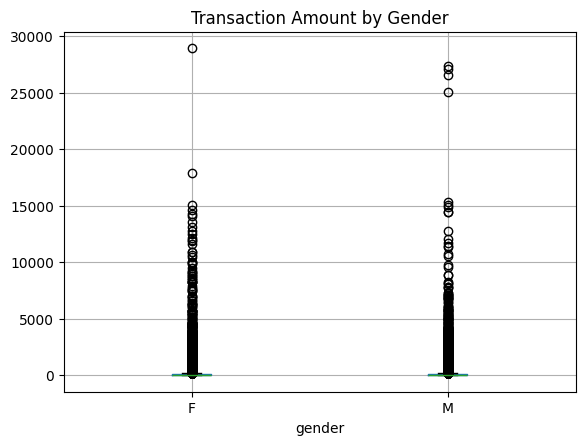

In [26]:
df.boxplot(column='amt', by='gender')
plt.title("Transaction Amount by Gender")
plt.suptitle("")
plt.show()

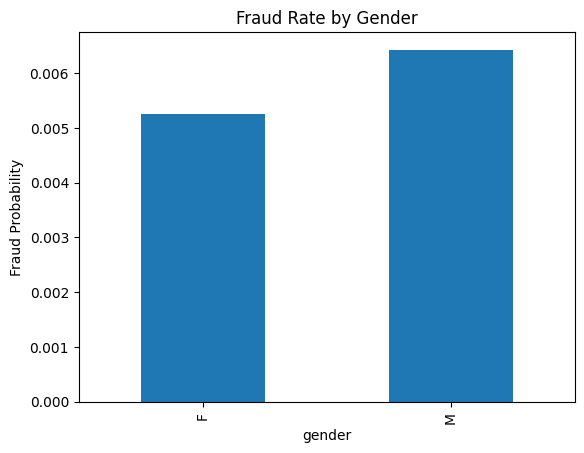

In [27]:
df.groupby('gender')['is_fraud'].mean().plot(kind='bar')
plt.title("Fraud Rate by Gender")
plt.ylabel("Fraud Probability")
plt.show()

In [28]:
df.groupby('category')['amt'].mean().sort_values(ascending=False).head(10)

category
grocery_pos      116.960986
travel           111.504720
shopping_net      88.424076
misc_net          80.865095
shopping_pos      79.779155
entertainment     64.210421
gas_transport     63.434572
misc_pos          62.890999
home              58.270139
kids_pets         57.536871
Name: amt, dtype: float64

In [29]:
df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(10)

category
shopping_net     0.017561
misc_net         0.014458
grocery_pos      0.014098
shopping_pos     0.007225
gas_transport    0.004694
misc_pos         0.003139
grocery_net      0.002948
travel           0.002864
entertainment    0.002478
personal_care    0.002424
Name: is_fraud, dtype: float64

## EDA (Multivariate Analysis)

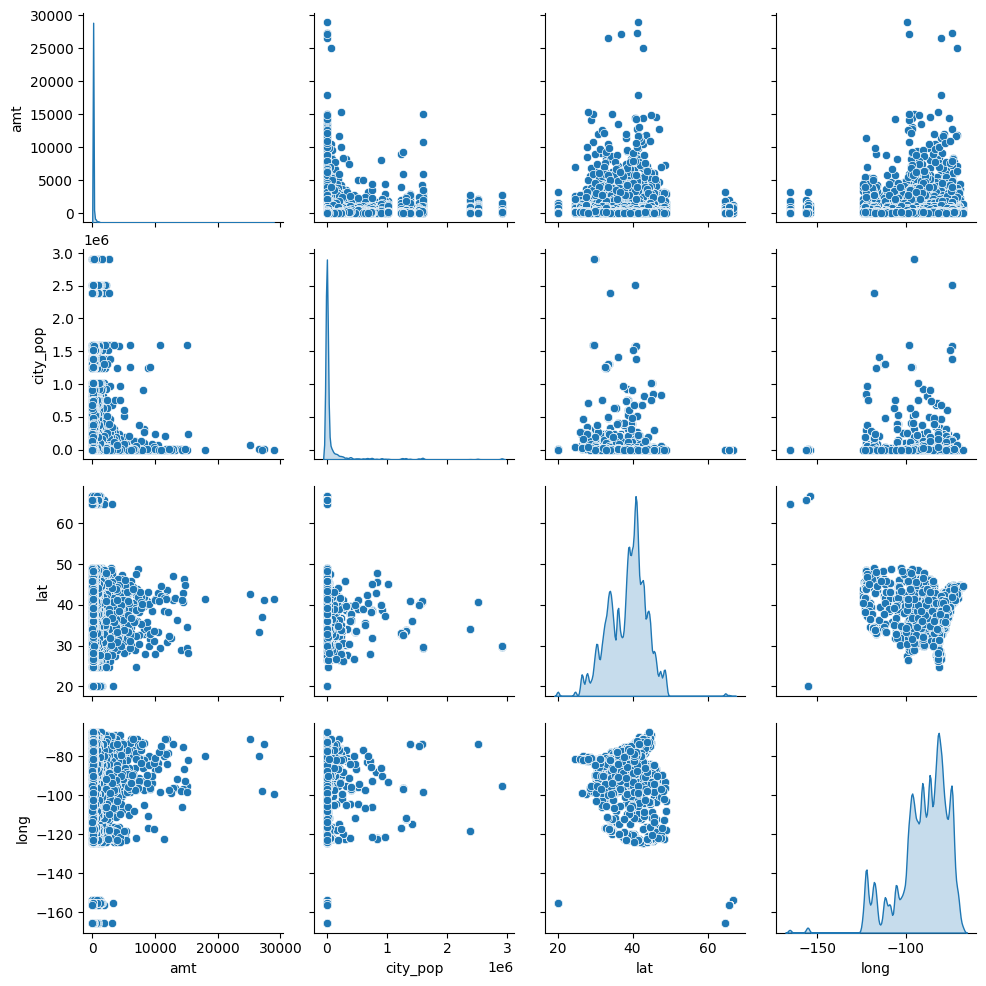

In [30]:
num_cols = ['amt', 'city_pop', 'lat', 'long']
sns.pairplot(df[num_cols], diag_kind='kde')

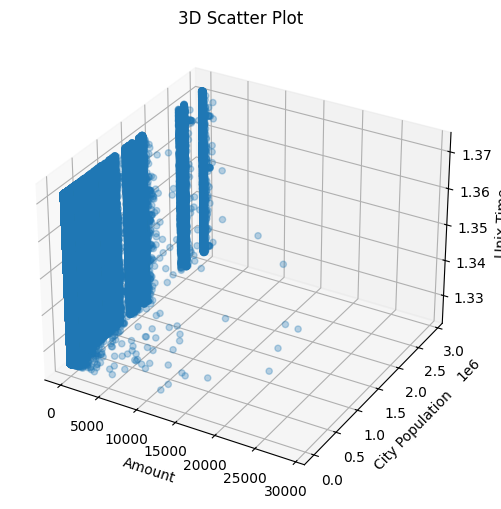

In [31]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['amt'], df['city_pop'], df['unix_time'], alpha=0.3)
ax.set_xlabel('Amount')
ax.set_ylabel('City Population')
ax.set_zlabel('Unix Time')
plt.title("3D Scatter Plot")
plt.show()

In [32]:
X = df[['amt', 'city_pop']]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [33]:
df['cluster'].value_counts()

cluster
2    1236014
1      49933
0      10728
Name: count, dtype: int64

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[-0.48819701, -0.08855615],
       [-0.04499363,  0.37031823],
       [ 0.46226568,  0.85882011],
       [-0.31528018,  0.09164821],
       [-0.33299756,  0.08254848]])

In [35]:
pca.explained_variance_ratio_

array([0.50290914, 0.49709086])

In [36]:
X_vif = df[['amt', 'city_pop', 'lat', 'long']]
X_vif = X_vif.dropna()

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data

,Feature,VIF
0,amt,1.190280
1,city_pop,1.102903
2,lat,26.155976
3,long,26.537008


## EDA (Outliers Analysis & Data Quality Checks)

In [37]:
df['amt_zscore'] = zscore(df['amt'])
outliers_z = df[df['amt_zscore'].abs() > 3]
outliers_z.shape

(12738, 26)

In [38]:
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df[(df['amt'] < Q1 - 1.5*IQR) | (df['amt'] > Q3 + 1.5*IQR)]
outliers_iqr.shape

(67290, 26)

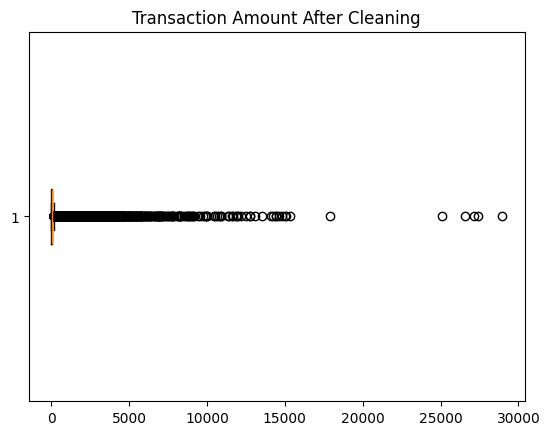

In [39]:
plt.boxplot(df['amt'], vert=False)
plt.title("Transaction Amount After Cleaning")
plt.show()

In [40]:
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365


In [41]:
df[df['age'] < 0]

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_log,cluster,amt_zscore,age


In [42]:
category_counts = df['category'].value_counts(normalize=True)

rare_categories = category_counts[category_counts < 0.01]
rare_categories

Series([], Name: proportion, dtype: float64)

## EDA (Insights & Reporting)

In [43]:
df_model = df.copy()

In [44]:
df_model['trans_date_trans_time'] = pd.to_datetime(df_model['trans_date_trans_time'])
df_model['dob'] = pd.to_datetime(df_model['dob'])

In [45]:
df_model['trans_hour'] = df_model['trans_date_trans_time'].dt.hour
df_model['trans_day'] = df_model['trans_date_trans_time'].dt.day
df_model['trans_month'] = df_model['trans_date_trans_time'].dt.month

df_model['age'] = (df_model['trans_date_trans_time'] - df_model['dob']).dt.days // 365

In [46]:
df_model.drop(['trans_date_trans_time', 'dob'], axis=1, inplace=True)

In [47]:
cat_cols = df_model.select_dtypes(include='object').columns
le = LabelEncoder()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [48]:
X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
feature_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

category      0.172349
trans_hour    0.129485
amt_log       0.114516
amt_zscore    0.108376
amt           0.103047
age           0.049240
cluster       0.034038
city_pop      0.024113
Unnamed: 0    0.019151
unix_time     0.019144
dtype: float64

### 🔹 EDA Summary & Key Findings

#### 🔑 Key Findings

- The dataset is **highly imbalanced**, with fraudulent transactions representing **less than 1%** of the total data.
- The transaction amount (`amt`) shows a **right-skewed distribution** with a large number of outliers.
- Detected outliers are **meaningful** and were **retained**, as they may indicate fraudulent behavior.
- Certain **transaction reminders** and **merchants** exhibit higher fraud rates compared to others.
- No strong **multicollinearity** was detected among numerical features.
- Overall **data quality is high**, with no missing values or logical inconsistencies.


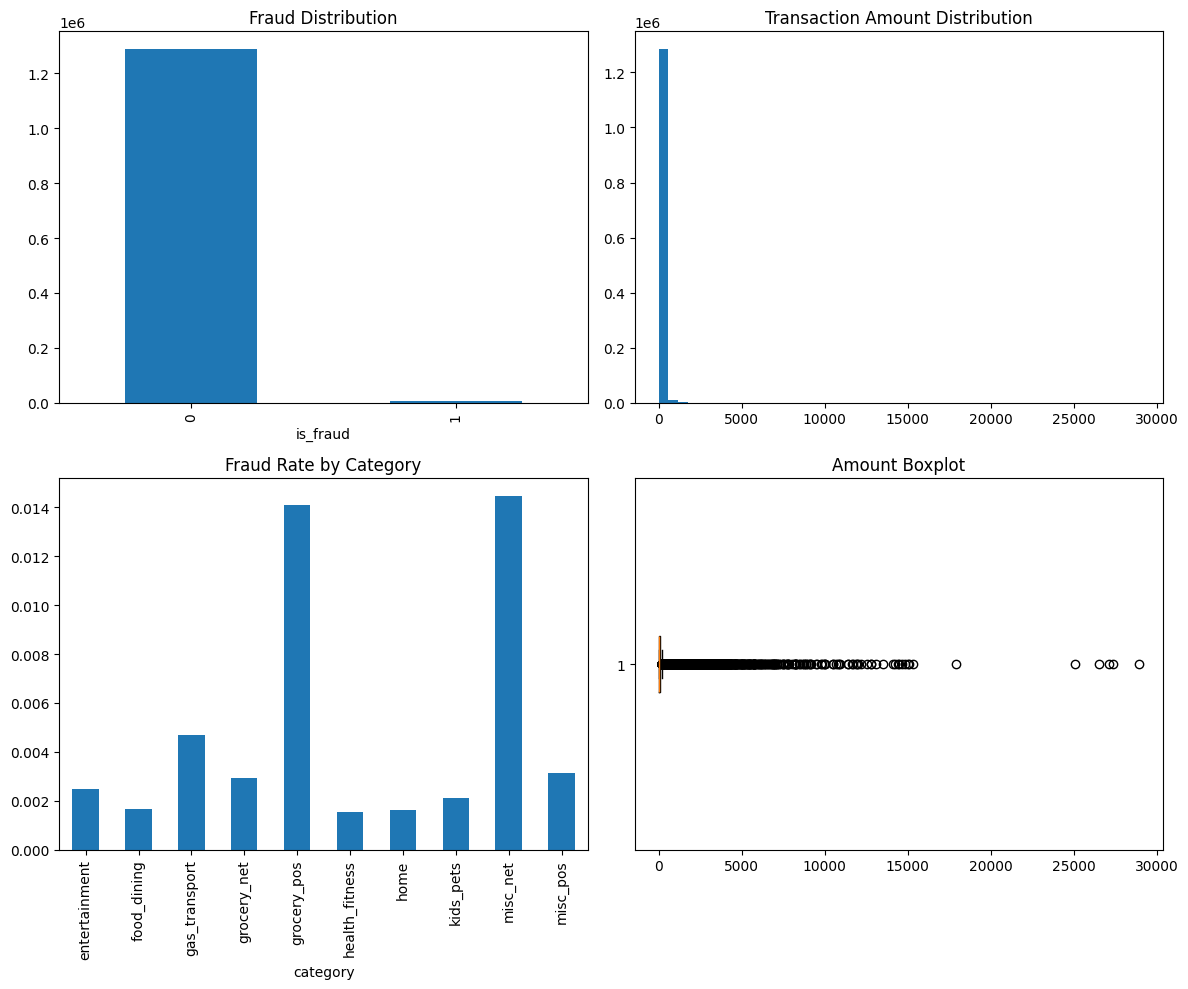

In [50]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))

df['is_fraud'].value_counts().plot(kind='bar', ax=axs[0,0], title='Fraud Distribution')

axs[0,1].hist(df['amt'], bins=50)
axs[0,1].set_title('Transaction Amount Distribution')

df.groupby('category')['is_fraud'].mean().head(10).plot(
    kind='bar', ax=axs[1,0], title='Fraud Rate by Category'
)

axs[1,1].boxplot(df['amt'], vert=False)
axs[1,1].set_title('Amount Boxplot')

plt.tight_layout()
plt.show()

# Data Preprocessing

In [51]:
df_prep = df.copy()

df_prep['trans_date_trans_time'] = pd.to_datetime(df_prep['trans_date_trans_time'])
df_prep['dob'] = pd.to_datetime(df_prep['dob'])

df_prep['trans_hour'] = df_prep['trans_date_trans_time'].dt.hour
df_prep['trans_day'] = df_prep['trans_date_trans_time'].dt.day
df_prep['trans_month'] = df_prep['trans_date_trans_time'].dt.month

df_prep['age'] = (df_prep['trans_date_trans_time'] - df_prep['dob']).dt.days // 365

df_prep.drop(['trans_date_trans_time', 'dob'], axis=1, inplace=True)


In [52]:
cat_cols = df_prep.select_dtypes(include='object').columns
le = LabelEncoder()

for col in cat_cols:
    df_prep[col] = le.fit_transform(df_prep[col])

In [53]:
scaler = RobustScaler()

In [54]:
num_cols = df_prep.drop('is_fraud', axis=1).columns
df_prep[num_cols] = scaler.fit_transform(df_prep[num_cols])

In [55]:
X = df_prep.drop('is_fraud', axis=1)
y = df_prep['is_fraud']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [58]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
is_fraud
0    1031335
1       6005
Name: count, dtype: int64

After SMOTE:
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


In [93]:
def evaluate_model(model=None, X_test=None, y_test=None, y_pred=None, y_prob=None):
    
    if model is not None:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    
    if y_prob is not None:
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [60]:
lr = LogisticRegression(solver='saga', max_iter=3000, class_weight='balanced')
lr.fit(X_train, y_train)

evaluate_model(lr, X_test, y_test)

c:\Users\maria\miniconda3\envs\selenium\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 0.8547592881793818
Precision: 0.030531972895085288
Recall: 0.7834776815456362
F1-score: 0.05877355190164426
ROC-AUC: 0.8792551360726819

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92    257834
           1       0.03      0.78      0.06      1501

    accuracy                           0.85    259335
   macro avg       0.51      0.82      0.49    259335
weighted avg       0.99      0.85      0.92    259335

Confusion Matrix:
 [[220493  37341]
 [   325   1176]]


In [61]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

evaluate_model(dt, X_test, y_test)

Accuracy: 0.9977557984845856
Precision: 0.8001306335728282
Recall: 0.8161225849433711
F1-score: 0.808047493403694
ROC-AUC: 0.9074678874126165

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.80      0.82      0.81      1501

    accuracy                           1.00    259335
   macro avg       0.90      0.91      0.90    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
 [[257528    306]
 [   276   1225]]


In [62]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

evaluate_model(rf, X_test, y_test)

Accuracy: 0.9984730175255943
Precision: 0.9750644883920895
Recall: 0.7554963357761493
F1-score: 0.8513513513513513
ROC-AUC: 0.9929620857181778

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.98      0.76      0.85      1501

    accuracy                           1.00    259335
   macro avg       0.99      0.88      0.93    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
 [[257805     29]
 [   367   1134]]


In [63]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

evaluate_model(gb, X_test, y_test)

Accuracy: 0.9970694275743729
Precision: 0.819672131147541
Recall: 0.6329113924050633
F1-score: 0.7142857142857143
ROC-AUC: 0.9737419314309501

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.82      0.63      0.71      1501

    accuracy                           1.00    259335
   macro avg       0.91      0.82      0.86    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
 [[257625    209]
 [   551    950]]


In [64]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)

evaluate_model(ada, X_test, y_test)

Accuracy: 0.9958277903098309
Precision: 0.8218125960061444
Recall: 0.3564290473017988
F1-score: 0.4972118959107807
ROC-AUC: 0.9827816385193936

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.82      0.36      0.50      1501

    accuracy                           1.00    259335
   macro avg       0.91      0.68      0.75    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
 [[257718    116]
 [   966    535]]


In [65]:
et = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42
)
et.fit(X_train, y_train)

evaluate_model(et, X_test, y_test)

Accuracy: 0.9981876723157306
Precision: 0.9849482596425212
Recall: 0.6975349766822119
F1-score: 0.8166926677067082
ROC-AUC: 0.9966664171805444

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.98      0.70      0.82      1501

    accuracy                           1.00    259335
   macro avg       0.99      0.85      0.91    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
 [[257818     16]
 [   454   1047]]


In [66]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)
evaluate_model(xgb, X_test, y_test)

Accuracy: 0.9990591320107197
Precision: 0.976497346474602
Recall: 0.8580946035976016
F1-score: 0.9134751773049645
ROC-AUC: 0.99937763177778

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.98      0.86      0.91      1501

    accuracy                           1.00    259335
   macro avg       0.99      0.93      0.96    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
 [[257803     31]
 [   213   1288]]


In [68]:
X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

X_train_lgbm.columns = (
    X_train_lgbm.columns
    .str.replace('[^A-Za-z0-9_]+', '', regex=True)
)

X_test_lgbm.columns = X_train_lgbm.columns

In [69]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train_lgbm, y_train)
evaluate_model(lgbm, X_test_lgbm, y_test)

[LightGBM] [Info] Number of positive: 6005, number of negative: 1031335
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5033
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146017
[LightGBM] [Info] Start training from score -5.146017
Accuracy: 0.9981992403647791
Precision: 0.8560606060606061
Recall: 0.8281145902731513
F1-score: 0.8418557399254994
ROC-AUC: 0.9947842740974745

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.86      0.83      0.84      1501

    accuracy                           1.00    259335
   macro avg       0.93      0.91      0.92    259335

In [70]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='minkowski'
)

knn.fit(X_train, y_train)
evaluate_model(knn, X_test, y_test)

Accuracy: 0.9962133919447819
Precision: 0.7817589576547231
Recall: 0.47968021319120585
F1-score: 0.5945499587118084
ROC-AUC: 0.8930009024031736

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.78      0.48      0.59      1501

    accuracy                           1.00    259335
   macro avg       0.89      0.74      0.80    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
 [[257633    201]
 [   781    720]]


In [72]:
ensemble_soft = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('et', et)
    ],
    voting='soft'
)

ensemble_soft.fit(X_train_smote, y_train_smote)
evaluate_model(ensemble_soft, X_test, y_test)

Accuracy: 0.9983072088225654
Precision: 0.850263852242744
Recall: 0.8587608261159227
F1-score: 0.8544912164401723
ROC-AUC: 0.9981552953388139

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.85      0.86      0.85      1501

    accuracy                           1.00    259335
   macro avg       0.92      0.93      0.93    259335
weighted avg       1.00      1.00      1.00    259335

Confusion Matrix:
 [[257607    227]
 [   212   1289]]


In [80]:
svm = LinearSVC(class_weight='balanced', max_iter=2000)
svm.fit(X_train_smote, y_train_smote)

y_pred_svm = svm.predict(X_test)
evaluate_model(svm, X_test, y_test)

Accuracy: 0.9581776466732219
Precision: 0.09695505908738032
Recall: 0.748834110592938
F1-score: 0.17168168626851993

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98    257834
           1       0.10      0.75      0.17      1501

    accuracy                           0.96    259335
   macro avg       0.55      0.85      0.58    259335
weighted avg       0.99      0.96      0.97    259335

Confusion Matrix:
 [[247365  10469]
 [   377   1124]]


In [84]:
nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)

y_pred_nb = nb.predict(X_test)
evaluate_model(nb, X_test, y_test)

Accuracy: 0.9434013920219022
Precision: 0.06038566757856809
Recall: 0.6029313790806129
F1-score: 0.10977680737506065
ROC-AUC: 0.8415717456206697

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97    257834
           1       0.06      0.60      0.11      1501

    accuracy                           0.94    259335
   macro avg       0.53      0.77      0.54    259335
weighted avg       0.99      0.94      0.97    259335

Confusion Matrix:
 [[243752  14082]
 [   596    905]]


In [86]:
brf = BalancedRandomForestClassifier(
    n_estimators=300,
    random_state=42
)

brf.fit(X_train, y_train)
evaluate_model(brf, X_test, y_test)

Accuracy: 0.9848419997300789
Precision: 0.2687476208602969
Recall: 0.9407061958694204
F1-score: 0.41806069578090305
ROC-AUC: 0.9964450798557223

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.27      0.94      0.42      1501

    accuracy                           0.98    259335
   macro avg       0.63      0.96      0.71    259335
weighted avg       1.00      0.98      0.99    259335

Confusion Matrix:
 [[253992   3842]
 [    89   1412]]


In [102]:
joblib.dump(brf, "../Model/brf_final_model.pkl")

['../Model/brf_final_model.pkl']

In [103]:
joblib.dump(X_train.columns.tolist(), "../Model/brf_features.pkl")

['../Model/brf_features.pkl']